# 🔬 Notebook 2 — LFCC Feature Extraction
## Forensic Audio Authentication using Deep Learning

---
### 📂 Arborescence réelle confirmée
```
BASE = /kaggle/input/datasets/elmiz20042004

Authentiques LJSpeech original :
  BASE/forensic-audio-dataset/LJSpeech-1.1/LJSpeech-1.1/wavs/*.wav  (13100 clips)

Deepfakes WaveFake :
  BASE/forensic-audio-dataset/generated_audio/generated_audio/ljspeech_melgan/*.wav
  BASE/forensic-audio-dataset/generated_audio/generated_audio/ljspeech_waveglow/*.wav
  ... (6 vocoders)

ASVspoof2019 LA :
  BASE/forensic-audio-dataset/LA/LA/ASVspoof2019_LA_train/flac/*.flac  (25380)
  BASE/forensic-audio-dataset/LA/LA/ASVspoof2019_LA_dev/flac/*.flac    (24986)
  BASE/forensic-audio-dataset/LA/LA/ASVspoof2019_LA_eval/flac/*.flac   (71933)
  BASE/forensic-audio-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/

Splices simulés :
  BASE/audio-preprocessing/spliced/splice_*.wav  (1000 clips)

LJSpeech 16kHz rééchantillonné :
  BASE/audio-preprocessing/ljspeech_16k/*.wav  (13100 clips)

Labels :
  BASE/audio-preprocessing/splits/master_labels.csv
```

---
## CELLULE 1 — Imports + GPU

In [1]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'GPU dispo : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'Device   : {device}')
print('✅ Imports OK')

PyTorch  : 2.10.0+cu128
GPU dispo : True
GPU      : Tesla T4
Device   : cuda
✅ Imports OK


---
## CELLULE 2 — Paramètres + Chemins exacts

In [2]:
# ── Paramètres audio & LFCC ───────────────────────────────────────────────────
SAMPLE_RATE   = 16000
CLIP_DURATION = 4
CLIP_SAMPLES  = SAMPLE_RATE * CLIP_DURATION   # 64 000
N_LFCC        = 20
N_FFT         = 400
HOP_LENGTH    = 160
N_FILTER      = 128
N_FRAMES      = 400

# ── Chemins exacts confirmés par le diagnostic ─────────────────────────────────
BASE     = Path('/kaggle/input/datasets/elmiz20042004')
PREPROC  = BASE / 'audio-preprocessing'
FORENSIC = BASE / 'forensic-audio-dataset'

# Fichiers authentiques LJSpeech ORIGINAL (22050Hz → à rééchantillonner)
LJ_ORIG_DIR  = FORENSIC / 'LJSpeech-1.1/LJSpeech-1.1/wavs'

# LJSpeech déjà rééchantillonné à 16kHz (Notebook 1)
LJ_16K_DIR   = PREPROC / 'ljspeech_16k'

# WaveFake (deepfakes par vocoder)
WAVEFAKE_DIR = FORENSIC / 'generated_audio/generated_audio'

# ASVspoof2019 LA
ASV_DIR      = FORENSIC / 'LA/LA'
ASV_TRAIN    = ASV_DIR / 'ASVspoof2019_LA_train'
ASV_DEV      = ASV_DIR / 'ASVspoof2019_LA_dev'
ASV_EVAL     = ASV_DIR / 'ASVspoof2019_LA_eval'
ASV_PROTO    = ASV_DIR / 'ASVspoof2019_LA_cm_protocols'

# Splices simulés
SPLICED_DIR  = PREPROC / 'spliced'

# Labels
MASTER_CSV   = PREPROC / 'splits' / 'master_labels.csv'

# Output
OUTPUT_DIR   = Path('/kaggle/working')
FEATURES_DIR = OUTPUT_DIR / 'lfcc_features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Vérification ─────────────────────────────────────────────────────────────
print('Vérification des chemins :')
print('=' * 62)
paths = [
    ('LJSpeech original (22kHz)', LJ_ORIG_DIR),
    ('LJSpeech 16kHz',            LJ_16K_DIR),
    ('WaveFake vocoders',          WAVEFAKE_DIR),
    ('ASVspoof train/flac',        ASV_TRAIN / 'flac'),
    ('ASVspoof dev/flac',          ASV_DEV   / 'flac'),
    ('ASVspoof eval/flac',         ASV_EVAL  / 'flac'),
    ('ASVspoof protocols',         ASV_PROTO),
    ('Splices simulés',            SPLICED_DIR),
    ('master_labels.csv',          MASTER_CSV),
    ('lfcc_features/ (output)',    FEATURES_DIR),
]
for name, path in paths:
    exists = Path(path).exists()
    icon   = '✅' if exists else '❌'
    count  = ''
    if exists and Path(path).is_dir():
        n = len(list(Path(path).iterdir()))
        count = f'  ({n:,} éléments)'
    print(f'  {icon} {name:30s} {count}')

print(f'\nParamètres LFCC :')
print(f'  {SAMPLE_RATE}Hz | {CLIP_DURATION}s | {N_LFCC} coeff | shape finale ({N_LFCC},{N_FRAMES})')

Vérification des chemins :
  ✅ LJSpeech original (22kHz)        (13,100 éléments)
  ✅ LJSpeech 16kHz                   (13,100 éléments)
  ✅ WaveFake vocoders                (8 éléments)
  ✅ ASVspoof train/flac              (25,380 éléments)
  ✅ ASVspoof dev/flac                (24,986 éléments)
  ✅ ASVspoof eval/flac               (71,933 éléments)
  ✅ ASVspoof protocols               (3 éléments)
  ✅ Splices simulés                  (1,001 éléments)
  ✅ master_labels.csv              
  ✅ lfcc_features/ (output)          (0 éléments)

Paramètres LFCC :
  16000Hz | 4s | 20 coeff | shape finale (20,400)


---
## CELLULE 3 — Fonctions audio

In [3]:
def normalize_length(waveform, target=CLIP_SAMPLES):
    n = waveform.shape[1]
    if n >= target:
        s = (n - target) // 2
        return waveform[:, s:s+target]
    return F.pad(waveform, (0, target - n))


def normalize_amplitude(waveform, db=-20.0):
    rms = waveform.pow(2).mean().sqrt()
    if rms > 1e-8:
        waveform = waveform * (10**(db/20.0) / rms)
    return waveform.clamp(-1.0, 1.0)


def load_audio(filepath, target_sr=SAMPLE_RATE):
    """Charge .wav ou .flac → Tensor (1, 64000) normalisé à 16kHz."""
    waveform, sr = torchaudio.load(str(filepath))
    if sr != target_sr:
        waveform = T.Resample(orig_freq=sr, new_freq=target_sr)(waveform)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    waveform = normalize_length(waveform)
    waveform = normalize_amplitude(waveform)
    return waveform  # (1, 64000)


# ── Test rapide ───────────────────────────────────────────────────────────────
# Tester sur LJSpeech 16k (le plus propre)
lj16k_files = sorted(LJ_16K_DIR.glob('*.wav'))
print(f'LJSpeech 16k : {len(lj16k_files):,} fichiers')

test_wav = load_audio(lj16k_files[0])
print(f'Test load_audio : shape={test_wav.shape}, '
      f'min={test_wav.min():.3f}, max={test_wav.max():.3f}')
assert test_wav.shape == (1, CLIP_SAMPLES)
print('✅ Fonctions audio OK')

LJSpeech 16k : 13,100 fichiers
Test load_audio : shape=torch.Size([1, 64000]), min=-0.638, max=0.808
✅ Fonctions audio OK


---
## CELLULE 4 — Chargement du master_labels.csv

In [4]:
# ── Charger le CSV existant ───────────────────────────────────────────────────
if MASTER_CSV.exists():
    df = pd.read_csv(MASTER_CSV)
    print(f'✅ master_labels.csv chargé : {len(df):,} clips')
    print(f'   Colonnes : {list(df.columns)}')
    print(f'\n   Distribution labels :')
    print(f'   Authentique (0) : {(df.label==0).sum():,}')
    print(f'   Manipulé    (1) : {(df.label==1).sum():,}')
    print(f'\n   Distribution splits :')
    print(df['split'].value_counts().to_string())
    print(f'\n   Sources :')
    print(df['source_dataset'].value_counts().to_string())
else:
    raise FileNotFoundError(
        f'master_labels.csv non trouvé à {MASTER_CSV}\n'
        'Exécuter le Notebook 1 en premier.'
    )

# ── Vérifier/corriger les chemins dans le CSV ─────────────────────────────────
# Le CSV a été créé dans une session précédente avec des chemins /kaggle/working/
# On doit les corriger pour pointer vers /kaggle/input/
print('\n🔄 Vérification et correction des chemins dans le CSV...')

def fix_filepath(fp):
    """
    Corrige les chemins du CSV qui pointent vers /kaggle/working/
    (session expirée) vers les vrais chemins /kaggle/input/
    """
    fp = str(fp)
    p  = Path(fp)

    # Si le fichier existe déjà tel quel → OK
    if p.exists():
        return fp

    fname = p.name
    stem  = p.stem

    # LJSpeech 16k
    candidate = LJ_16K_DIR / fname
    if candidate.exists():
        return str(candidate)

    # Splices simulés
    candidate = SPLICED_DIR / fname
    if candidate.exists():
        return str(candidate)

    # ASVspoof — chercher dans train/dev/eval
    for asv_split in [ASV_TRAIN, ASV_DEV, ASV_EVAL]:
        for ext in ['.flac', '.wav']:
            candidate = asv_split / 'flac' / (stem + ext)
            if candidate.exists():
                return str(candidate)

    # WaveFake — chercher dans tous les vocoders
    if WAVEFAKE_DIR.exists():
        for vdir in WAVEFAKE_DIR.iterdir():
            if not vdir.is_dir(): continue
            candidate = vdir / fname
            if candidate.exists():
                return str(candidate)

    # LJSpeech original
    candidate = LJ_ORIG_DIR / fname
    if candidate.exists():
        return str(candidate)

    return fp  # retourner l'original si introuvable


# Appliquer la correction sur un échantillon d'abord
sample_check = df.head(20).copy()
sample_check['filepath_fixed'] = sample_check['filepath'].apply(fix_filepath)
n_found    = sample_check['filepath_fixed'].apply(lambda x: Path(x).exists()).sum()
n_missing  = 20 - n_found
print(f'   Test sur 20 clips : {n_found}/20 fichiers trouvés')

if n_found >= 15:
    print('   ✅ Correction des chemins fonctionne — application sur tout le dataset')
    df['filepath'] = df['filepath'].apply(fix_filepath)
    df['accessible'] = df['filepath'].apply(lambda x: Path(x).exists())
    n_accessible = df['accessible'].sum()
    print(f'   Clips accessibles : {n_accessible:,}/{len(df):,} ({n_accessible/len(df)*100:.1f}%)')
    df_valid = df[df['accessible']].copy()
    print(f'   Dataset valide    : {len(df_valid):,} clips')
else:
    print(f'   ⚠️  Seulement {n_found}/20 trouvés — affichage pour debug :')
    for _, r in sample_check.iterrows():
        ok = '✅' if Path(r['filepath_fixed']).exists() else '❌'
        print(f'     {ok} {Path(r["filepath"]).name}')
    df_valid = df.copy()

display(df_valid.head(5))

✅ master_labels.csv chargé : 138,947 clips
   Colonnes : ['filename', 'filepath', 'label', 'system_id', 'tamper_type', 'source_dataset', 'source_clip1', 'source_clip2', 'splice_sample', 'splice_frame', 'splice_time_s', 'split']

   Distribution labels :
   Authentique (0) : 15,483
   Manipulé    (1) : 123,464

   Distribution splits :
split
train    135449
val        1749
test       1749

   Sources :
source_dataset
asvspoof2019_la       121461
wavefake               13486
ljspeech                3000
ljspeech_simulated      1000

🔄 Vérification et correction des chemins dans le CSV...
   Test sur 20 clips : 20/20 fichiers trouvés
   ✅ Correction des chemins fonctionne — application sur tout le dataset
   Clips accessibles : 138,947/138,947 (100.0%)
   Dataset valide    : 138,947 clips


,filename,filepath,label,system_id,tamper_type,source_dataset,source_clip1,source_clip2,splice_sample,splice_frame,splice_time_s,split,accessible
0,LA_E_3706860,/kaggle/input/datasets/elmiz20042004/forensic-...,0,-,authentic,asvspoof2019_la,NaN,NaN,NaN,NaN,NaN,train,True
1,LJ038-0226.wav,/kaggle/input/datasets/elmiz20042004/audio-pre...,0,-,authentic,ljspeech,NaN,NaN,NaN,NaN,NaN,train,True
2,LA_E_5861385,/kaggle/input/datasets/elmiz20042004/forensic-...,1,A13,deepfake_tts_A13,asvspoof2019_la,NaN,NaN,NaN,NaN,NaN,train,True
3,LA_E_2353143,/kaggle/input/datasets/elmiz20042004/forensic-...,1,A09,deepfake_tts_A09,asvspoof2019_la,NaN,NaN,NaN,NaN,NaN,train,True
4,LA_E_3398570,/kaggle/input/datasets/elmiz20042004/forensic-...,1,A19,deepfake_tts_A19,asvspoof2019_la,NaN,NaN,NaN,NaN,NaN,train,True


---
## CELLULE 5 — Fonction d'extraction LFCC

In [5]:
# ── Transform LFCC — UNE SEULE instance réutilisée ───────────────────────────
lfcc_transform = T.LFCC(
    sample_rate = SAMPLE_RATE,
    n_filter    = N_FILTER,
    n_lfcc      = N_LFCC,
    speckwargs  = {
        'n_fft'      : N_FFT,
        'hop_length' : HOP_LENGTH,
        'win_length' : N_FFT,
    }
)


def extract_lfcc(waveform, target_frames=N_FRAMES):
    """
    waveform Tensor (1, 64000) → numpy array (20, 400) float32

    Étapes :
    1. LFCC transform → (1, 20, ~400)
    2. CMVN normalization (moyenne=0, std=1 par coefficient)
    3. Ajustement à exactement 400 frames
    """
    with torch.no_grad():
        lfcc = lfcc_transform(waveform)  # (1, 20, ~400)
    lfcc = lfcc.squeeze(0)               # (20, ~400)

    # CMVN
    mean = lfcc.mean(dim=1, keepdim=True)
    std  = lfcc.std(dim=1,  keepdim=True)
    lfcc = (lfcc - mean) / (std + 1e-8)

    # Ajuster frames
    n = lfcc.shape[1]
    if n >= target_frames:
        s    = (n - target_frames) // 2
        lfcc = lfcc[:, s:s+target_frames]
    else:
        lfcc = F.pad(lfcc, (0, target_frames - n))

    return lfcc.numpy().astype(np.float32)  # (20, 400)


def extract_lfcc_from_file(filepath):
    """Pipeline complet : chemin fichier → numpy (20, 400)"""
    waveform = load_audio(filepath)
    return extract_lfcc(waveform)


# ── Test sur les 3 types de clips ────────────────────────────────────────────
print('Tests extraction LFCC :')
print('=' * 55)

test_cases = [
    ('LJSpeech 16k (authentique)', LJ_16K_DIR / 'LJ001-0001.wav'),
    ('Splice simulé',              SPLICED_DIR / 'splice_00000.wav'),
]

# Ajouter un test WaveFake si disponible
if WAVEFAKE_DIR.exists():
    for vdir in sorted(WAVEFAKE_DIR.iterdir()):
        if vdir.is_dir():
            wavs = sorted(vdir.glob('*.wav'))
            if wavs:
                test_cases.append((f'WaveFake ({vdir.name})', wavs[0]))
                break

# Ajouter un test ASVspoof si disponible
asv_flacs = sorted((ASV_TRAIN / 'flac').glob('*.flac'))
if asv_flacs:
    test_cases.append(('ASVspoof .flac', asv_flacs[0]))

for name, fpath in test_cases:
    if not Path(fpath).exists():
        print(f'  ⚠️  {name:30s} → fichier manquant')
        continue
    try:
        t0   = time.time()
        lfcc = extract_lfcc_from_file(fpath)
        ms   = (time.time() - t0) * 1000
        ok   = lfcc.shape == (N_LFCC, N_FRAMES) and lfcc.dtype == np.float32
        icon = '✅' if ok else '❌'
        print(f'  {icon} {name:30s} shape={lfcc.shape} '
              f'mean={lfcc.mean():.3f} std={lfcc.std():.3f} ({ms:.0f}ms)')
    except Exception as e:
        print(f'  ❌ {name:30s} ERREUR : {e}')

Tests extraction LFCC :
  ✅ LJSpeech 16k (authentique)     shape=(20, 400) mean=-0.000 std=0.999 (199ms)
  ✅ Splice simulé                  shape=(20, 400) mean=-0.000 std=0.999 (23ms)
  ✅ WaveFake (jsut_multi_band_melgan) shape=(20, 400) mean=0.001 std=1.000 (217ms)
  ✅ ASVspoof .flac                 shape=(20, 400) mean=0.001 std=1.000 (19ms)


---
## CELLULE 6 — Visualisation LFCC : Authentique vs Splice vs Deepfake

✅ Authentique : LJ001-0001.wav
✅ Splice : splice_00000.wav
✅ Deepfake (melgan_large) : LJ001-0001_gen.wav
✅ ASVspoof spoof : LA_T_1004644.flac

4 types de clips prêts
✅ Authentique (LJSpeech) — shape (20, 400)
✅ Splice (simulé) — shape (20, 400)
✅ Deepfake (melgan_large) — shape (20, 400)
✅ Deepfake TTS (ASVspoof) — shape (20, 400)


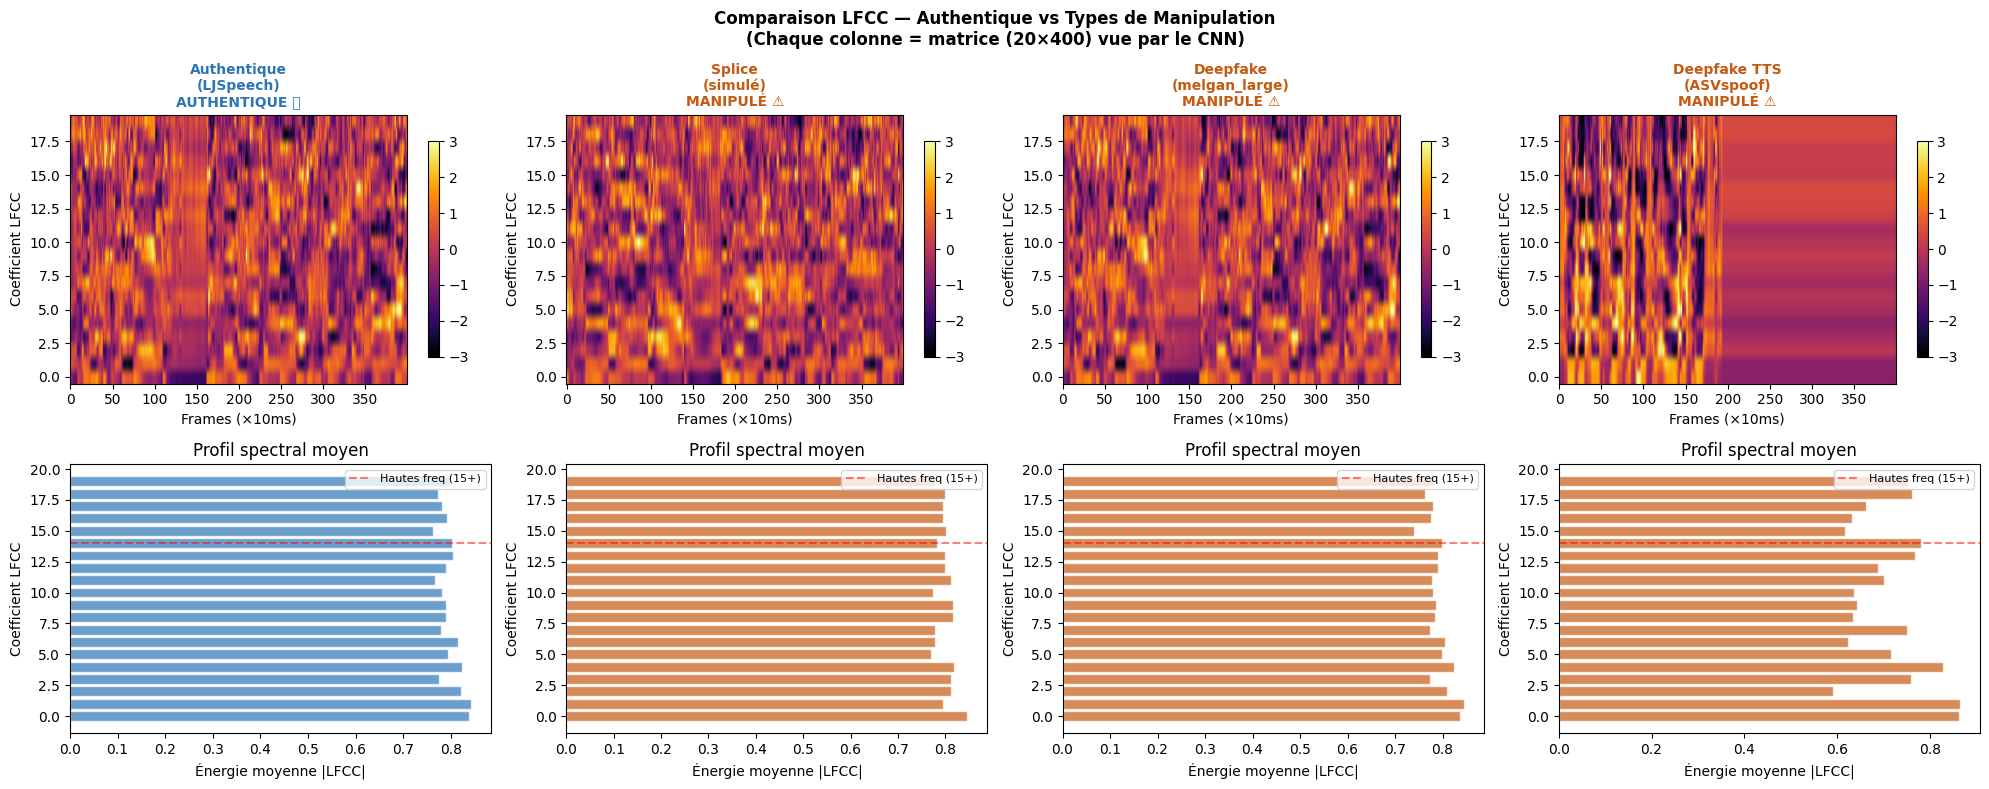

✅ lfcc_comparison.png sauvé


In [6]:
# ── Construire les samples avec les VRAIS chemins ────────────────────────────
samples = {}

# 1. Authentique — LJSpeech 16k (déjà rééchantillonné)
lj_files = sorted(LJ_16K_DIR.glob('*.wav'))
if lj_files:
    samples['Authentique\n(LJSpeech)'] = {
        'filepath': str(lj_files[0]), 'label': 0,
        'tamper_type': 'authentic', 'source_dataset': 'ljspeech'
    }
    print(f'✅ Authentique : {lj_files[0].name}')

# 2. Splice simulé
splice_files = sorted(SPLICED_DIR.glob('splice_*.wav'))
if splice_files:
    samples['Splice\n(simulé)'] = {
        'filepath': str(splice_files[0]), 'label': 1,
        'tamper_type': 'splice', 'source_dataset': 'ljspeech_simulated'
    }
    print(f'✅ Splice : {splice_files[0].name}')

# 3. Deepfake WaveFake (prendre melgan — le plus riche)
if WAVEFAKE_DIR.exists():
    # Préférer melgan_large ou melgan
    preferred = ['ljspeech_melgan_large', 'ljspeech_melgan', 'ljspeech_waveglow']
    for vname in preferred:
        vdir = WAVEFAKE_DIR / vname
        if vdir.exists():
            wavs = sorted(vdir.glob('*.wav'))
            if wavs:
                label = vname.replace('ljspeech_', '')
                samples[f'Deepfake\n({label})'] = {
                    'filepath': str(wavs[0]), 'label': 1,
                    'tamper_type': f'deepfake_{vname}',
                    'source_dataset': 'wavefake'
                }
                print(f'✅ Deepfake ({label}) : {wavs[0].name}')
                break

# 4. ASVspoof (deepfake TTS)
asv_flacs = sorted((ASV_TRAIN / 'flac').glob('*.flac'))
if asv_flacs:
    # Chercher un clip spoof dans le protocole
    proto_file = ASV_PROTO / 'ASVspoof2019.LA.cm.train.trn.txt'
    spoof_name = None
    if proto_file.exists():
        with open(proto_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5 and parts[4] == 'spoof':
                    spoof_name = parts[1]
                    break
    if spoof_name:
        spoof_path = ASV_TRAIN / 'flac' / f'{spoof_name}.flac'
        if spoof_path.exists():
            samples['Deepfake TTS\n(ASVspoof)'] = {
                'filepath': str(spoof_path), 'label': 1,
                'tamper_type': 'deepfake_tts', 'source_dataset': 'asvspoof'
            }
            print(f'✅ ASVspoof spoof : {spoof_name}.flac')

print(f'\n{len(samples)} types de clips prêts')

# ── Visualisation ─────────────────────────────────────────────────────────────
n_cols = len(samples)
fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

fig.suptitle(
    'Comparaison LFCC — Authentique vs Types de Manipulation\n'
    '(Chaque colonne = matrice (20×400) vue par le CNN)',
    fontsize=12, fontweight='bold'
)

lfcc_cache = {}

for ci, (title, row) in enumerate(samples.items()):
    try:
        lfcc = extract_lfcc_from_file(row['filepath'])
        lfcc_cache[title] = lfcc
        color      = '#2E75B6' if row['label'] == 0 else '#C55A11'
        label_text = 'AUTHENTIQUE ✅' if row['label'] == 0 else 'MANIPULÉ ⚠️'

        # Matrice LFCC
        im = axes[0, ci].imshow(
            lfcc, aspect='auto', origin='lower',
            cmap='inferno', vmin=-3, vmax=3
        )
        axes[0, ci].set_title(f'{title}\n{label_text}',
                               fontsize=10, color=color, fontweight='bold')
        axes[0, ci].set_xlabel('Frames (×10ms)')
        axes[0, ci].set_ylabel('Coefficient LFCC')
        plt.colorbar(im, ax=axes[0, ci], shrink=0.8)

        # Profil spectral
        coeff_energy = np.abs(lfcc).mean(axis=1)
        axes[1, ci].barh(range(N_LFCC), coeff_energy,
                          color=color, alpha=0.7, edgecolor='white')
        axes[1, ci].axhline(y=14, color='red', linestyle='--',
                             alpha=0.5, label='Hautes freq (15+)')
        axes[1, ci].set_xlabel('Énergie moyenne |LFCC|')
        axes[1, ci].set_ylabel('Coefficient LFCC')
        axes[1, ci].set_title('Profil spectral moyen')
        axes[1, ci].legend(fontsize=8)

        print(f'✅ {title.replace(chr(10)," ")} — shape {lfcc.shape}')

    except Exception as e:
        axes[0, ci].text(0.5, 0.5, f'Erreur:\n{str(e)[:60]}',
                          ha='center', va='center',
                          transform=axes[0, ci].transAxes, fontsize=8)
        print(f'❌ {title.replace(chr(10)," ")} : {e}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lfcc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ lfcc_comparison.png sauvé')

---
## CELLULE 7 — Construction du DataFrame complet avec tous les datasets

In [7]:
# ── Parser les protocoles ASVspoof ────────────────────────────────────────────
def parse_asv_protocol(proto_path, flac_dir, split_name):
    records = []
    with open(proto_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            fname      = parts[1]
            label_str  = parts[4]  # 'bonafide' ou 'spoof'
            fpath      = Path(flac_dir) / f'{fname}.flac'
            if not fpath.exists(): continue
            records.append({
                'filename'      : fname,
                'filepath'      : str(fpath),
                'label'         : 0 if label_str == 'bonafide' else 1,
                'tamper_type'   : 'authentic' if label_str == 'bonafide' else f'deepfake_tts_{parts[3]}',
                'source_dataset': 'asvspoof2019_la',
                'split'         : split_name,
            })
    return records


# ── Construire le DataFrame complet ──────────────────────────────────────────
print('🔄 Construction du DataFrame complet...')
all_records = []

# 1. master_labels.csv déjà corrigé (LJSpeech + splices)
lj_splice_records = df_valid[
    df_valid['source_dataset'].isin(['ljspeech', 'ljspeech_simulated'])
].copy()
all_records.extend(lj_splice_records.to_dict('records'))
print(f'  LJSpeech + Splices    : {len(lj_splice_records):,}')

# 2. WaveFake — sous-ensemble équilibré (2000 par vocoder max)
wf_count = 0
if WAVEFAKE_DIR.exists():
    for vdir in sorted(WAVEFAKE_DIR.iterdir()):
        if not vdir.is_dir(): continue
        wavs = sorted(vdir.glob('*.wav'))
        # Limiter à 2000 par vocoder pour éviter déséquilibre extrême
        import random
        random.seed(SEED)
        sample = wavs[:2000] if len(wavs) > 2000 else wavs
        for w in sample:
            all_records.append({
                'filename'      : w.name,
                'filepath'      : str(w),
                'label'         : 1,
                'tamper_type'   : f'deepfake_{vdir.name}',
                'source_dataset': 'wavefake',
                'split'         : None,  # sera assigné après
            })
            wf_count += 1
print(f'  WaveFake              : {wf_count:,}')

# 3. ASVspoof — splits officiels (IMPORTANT : ne pas re-diviser)
proto_map = {
    'train': (ASV_PROTO / 'ASVspoof2019.LA.cm.train.trn.txt', ASV_TRAIN / 'flac'),
    'val'  : (ASV_PROTO / 'ASVspoof2019.LA.cm.dev.trl.txt',   ASV_DEV   / 'flac'),
    'test' : (ASV_PROTO / 'ASVspoof2019.LA.cm.eval.trl.txt',  ASV_EVAL  / 'flac'),
}
asv_total = 0
for split_name, (proto, flac_dir) in proto_map.items():
    if proto.exists() and flac_dir.exists():
        recs = parse_asv_protocol(proto, flac_dir, split_name)
        all_records.extend(recs)
        asv_total += len(recs)
        print(f'  ASVspoof {split_name:5s}         : {len(recs):,}')

# ── Créer le DataFrame final ──────────────────────────────────────────────────
df_full = pd.DataFrame(all_records)

# Assigner splits 80/10/10 aux WaveFake et autres sans split
no_split_mask = df_full['split'].isna()
no_split_idx  = df_full[no_split_mask].index.tolist()
import random; random.seed(SEED)
random.shuffle(no_split_idx)
n = len(no_split_idx)
df_full.loc[no_split_idx[:int(n*0.8)],  'split'] = 'train'
df_full.loc[no_split_idx[int(n*0.8):int(n*0.9)], 'split'] = 'val'
df_full.loc[no_split_idx[int(n*0.9):],  'split'] = 'test'

# Mélanger
df_full = df_full.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\n📊 Dataset complet :')
print(f'   Total             : {len(df_full):,}')
print(f'   Authentique (0)   : {(df_full.label==0).sum():,}')
print(f'   Manipulé    (1)   : {(df_full.label==1).sum():,}')
print(f'   Splits            : {df_full.split.value_counts().to_dict()}')
print(f'   Sources           :')
print(df_full['source_dataset'].value_counts().to_string())

🔄 Construction du DataFrame complet...
  LJSpeech + Splices    : 4,000
  WaveFake              : 13,486
  ASVspoof train         : 25,380
  ASVspoof val           : 24,844
  ASVspoof test          : 71,237

📊 Dataset complet :
   Total             : 138,947
   Authentique (0)   : 15,483
   Manipulé    (1)   : 123,464
   Splits            : {'test': 73003, 'train': 39353, 'val': 26591}
   Sources           :
source_dataset
asvspoof2019_la       121461
wavefake               13486
ljspeech                3000
ljspeech_simulated      1000


---
## CELLULE 8 — Extraction LFCC batch (reprend si interrompue)

In [8]:
def get_npy_path(filepath):
    """Génère le chemin .npy correspondant à un fichier audio."""
    return FEATURES_DIR / f'{Path(filepath).stem}.npy'


# Vérifier ce qui est déjà calculé
existing_npy  = set(f.stem for f in FEATURES_DIR.glob('*.npy'))
df_full['feature_path'] = df_full['filepath'].apply(lambda fp: str(get_npy_path(fp)))
df_full['done']         = df_full['filepath'].apply(lambda fp: Path(fp).stem in existing_npy)

todo = df_full[~df_full['done']]
print(f'📊 État extraction :')
print(f'   Total clips     : {len(df_full):,}')
print(f'   Déjà extraits   : {df_full["done"].sum():,}')
print(f'   Restants        : {len(todo):,}')

if len(todo) == 0:
    print('\n✅ Toutes les features existent — passer à la cellule suivante')
else:
    print(f'\n🔄 Extraction sur {len(todo):,} clips...')
    errors = []
    t0     = time.time()

    for _, row in tqdm(todo.iterrows(), total=len(todo), desc='Extraction LFCC'):
        try:
            lfcc = extract_lfcc_from_file(row['filepath'])
            np.save(str(get_npy_path(row['filepath'])), lfcc)
        except Exception as e:
            errors.append({'file': Path(row['filepath']).name, 'error': str(e)[:80]})

    elapsed = time.time() - t0
    n_done  = len(list(FEATURES_DIR.glob('*.npy')))

    print(f'\n✅ Extraction terminée en {elapsed/60:.1f} min')
    print(f'   .npy créés  : {n_done:,}')
    print(f'   Erreurs     : {len(errors)}')

    if errors:
        print('   Premières erreurs :')
        for e in errors[:5]:
            print(f'     {e["file"]} : {e["error"]}')
        pd.DataFrame(errors).to_csv(OUTPUT_DIR / 'extraction_errors.csv', index=False)

📊 État extraction :
   Total clips     : 138,947
   Déjà extraits   : 0
   Restants        : 138,947

🔄 Extraction sur 138,947 clips...


Extraction LFCC:   0%|          | 0/138947 [00:00<?, ?it/s]


✅ Extraction terminée en 39.0 min
   .npy créés  : 133,017
   Erreurs     : 22
   Premières erreurs :
     LJ014-0123_gen.wav : Failed to create AudioDecoder for /kaggle/input/datasets/elmiz20042004/forensic-
     LJ007-0225_gen.wav : Failed to create AudioDecoder for /kaggle/input/datasets/elmiz20042004/forensic-
     LJ017-0121_gen.wav : Failed to create AudioDecoder for /kaggle/input/datasets/elmiz20042004/forensic-
     LJ008-0164_gen.wav : Failed to create AudioDecoder for /kaggle/input/datasets/elmiz20042004/forensic-
     LJ002-0226_gen.wav : Failed to create AudioDecoder for /kaggle/input/datasets/elmiz20042004/forensic-


---
## CELLULE 9 — Sauvegarde du CSV final

In [9]:
# Mettre à jour le status
existing_npy_final    = set(f.stem for f in FEATURES_DIR.glob('*.npy'))
df_full['feature_exists'] = df_full['filepath'].apply(
    lambda fp: Path(fp).stem in existing_npy_final
)

df_valid_final = df_full[df_full['feature_exists']].copy()
df_valid_final = df_valid_final.drop(columns=['done', 'feature_exists'], errors='ignore')

out_csv = OUTPUT_DIR / 'master_labels_with_features.csv'
df_valid_final.to_csv(out_csv, index=False)

print(f'✅ CSV sauvé : {out_csv}')
print(f'   Clips valides   : {len(df_valid_final):,}')
print(f'   Authentique (0) : {(df_valid_final.label==0).sum():,}')
print(f'   Manipulé    (1) : {(df_valid_final.label==1).sum():,}')
print(f'   Splits          : {df_valid_final.split.value_counts().to_dict()}')

# Vérification finale
test_npy = np.load(df_valid_final['feature_path'].iloc[0])
assert test_npy.shape == (N_LFCC, N_FRAMES), f'Shape incorrecte : {test_npy.shape}'
assert test_npy.dtype == np.float32

n_npy    = len(list(FEATURES_DIR.glob('*.npy')))
size_mb  = n_npy * N_LFCC * N_FRAMES * 4 / 1e6

print(f'\n   Test .npy   : shape={test_npy.shape} dtype={test_npy.dtype} ✅')
print(f'   Total .npy  : {n_npy:,} fichiers ({size_mb:.0f} MB)')

print('\n' + '='*55)
print('🎉 NOTEBOOK 2 TERMINÉ AVEC SUCCÈS')
print('='*55)
print('\nOutputs dans /kaggle/working/ :')
print(f'  ✅ lfcc_features/                  ({n_npy:,} fichiers .npy)')
print(f'  ✅ master_labels_with_features.csv  ({len(df_valid_final):,} lignes)')
print(f'  ✅ lfcc_comparison.png')
print('\n⏭️  Prochain : Notebook 3 — CNN-BiLSTM Training')
print('   Input  : master_labels_with_features.csv + lfcc_features/*.npy')
print('   Output : best_model.pth + forensic_audio.onnx')

✅ CSV sauvé : /kaggle/working/master_labels_with_features.csv
   Clips valides   : 138,928
   Authentique (0) : 15,483
   Manipulé    (1) : 123,445
   Splits          : {'test': 73000, 'train': 39339, 'val': 26589}

   Test .npy   : shape=(20, 400) dtype=float32 ✅
   Total .npy  : 133,017 fichiers (4257 MB)

🎉 NOTEBOOK 2 TERMINÉ AVEC SUCCÈS

Outputs dans /kaggle/working/ :
  ✅ lfcc_features/                  (133,017 fichiers .npy)
  ✅ master_labels_with_features.csv  (138,928 lignes)
  ✅ lfcc_comparison.png

⏭️  Prochain : Notebook 3 — CNN-BiLSTM Training
   Input  : master_labels_with_features.csv + lfcc_features/*.npy
   Output : best_model.pth + forensic_audio.onnx
